# Fase 5: Comparación de Modelos de Series de Tiempo

Prophet vs. Holt-Winters vs. SARIMA para predecir la demanda de taxis en la zona más transitada.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print("Librerías cargadas.")

Librerías cargadas.


/opt/anaconda3/envs/Python313/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("Cargando y preparando datos...")
df = pd.read_parquet('../datos/procesados/demanda_top10_series_tiempo.parquet')

# Aislar Zona 237 (Upper East Side South)
df_zona = df[df['PULocationID'] == 237].copy()
df_zona = df_zona.sort_values('hora')
df_zona = df_zona.set_index('hora')
df_zona = df_zona.asfreq('h') # Forzar frecuencia horaria

# Variable objetivo
y = df_zona['total_viajes']

# Split Train / Test (Últimos 7 días = 168 horas para Test)
test_size = 168
train = y.iloc[:-test_size]
test = y.iloc[-test_size:]

print(f"Train size: {len(train)} horas")
print(f"Test size: {len(test)} horas")

Cargando y preparando datos...
Train size: 576 horas
Test size: 168 horas


In [3]:
print("Entrenando Prophet...")
# Prophet requiere un DataFrame con columnas 'ds' y 'y'
df_train_prophet = train.reset_index().rename(columns={'hora': 'ds', 'total_viajes': 'y'})

model_prophet = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
model_prophet.fit(df_train_prophet)

# Predicción
future = model_prophet.make_future_dataframe(periods=test_size, freq='h')
forecast_prophet = model_prophet.predict(future)

# Extraer solo las predicciones del test
pred_prophet = forecast_prophet.iloc[-test_size:]['yhat'].values

mae_prophet = mean_absolute_error(test, pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(test, pred_prophet))
print(f"Prophet - MAE: {mae_prophet:.2f}, RMSE: {rmse_prophet:.2f}")

Entrenando Prophet...


02:03:12 - cmdstanpy - INFO - Chain [1] start processing
02:03:12 - cmdstanpy - INFO - Chain [1] done processing


Prophet - MAE: 56.49, RMSE: 67.98


In [4]:
print("Entrenando Holt-Winters (Suavización Exponencial)...")
# Estacionalidad diaria s=24
model_hw = ExponentialSmoothing(train, seasonal_periods=24, trend='add', seasonal='add', initialization_method="estimated")
fit_hw = model_hw.fit()

# Predicción
pred_hw = fit_hw.forecast(test_size).values

mae_hw = mean_absolute_error(test, pred_hw)
rmse_hw = np.sqrt(mean_squared_error(test, pred_hw))
print(f"Holt-Winters - MAE: {mae_hw:.2f}, RMSE: {rmse_hw:.2f}")

Entrenando Holt-Winters (Suavización Exponencial)...
Holt-Winters - MAE: 83.83, RMSE: 102.75


In [5]:
print("Entrenando SARIMA...")
# SARIMA (1,0,1)x(1,0,1,24)
# Usamos un modelo ligero para asegurar convergencia rápida
model_sarima = SARIMAX(train, order=(1, 0, 1), seasonal_order=(1, 0, 1, 24), enforce_stationarity=False, enforce_invertibility=False)
fit_sarima = model_sarima.fit(disp=False)

# Predicción
pred_sarima = fit_sarima.forecast(steps=test_size).values

mae_sarima = mean_absolute_error(test, pred_sarima)
rmse_sarima = np.sqrt(mean_squared_error(test, pred_sarima))
print(f"SARIMA - MAE: {mae_sarima:.2f}, RMSE: {rmse_sarima:.2f}")

Entrenando SARIMA...
SARIMA - MAE: 57.82, RMSE: 81.50


Generando comparación visual...
Gráfica guardada en: ../resultados/graficos/comparacion_modelos.png


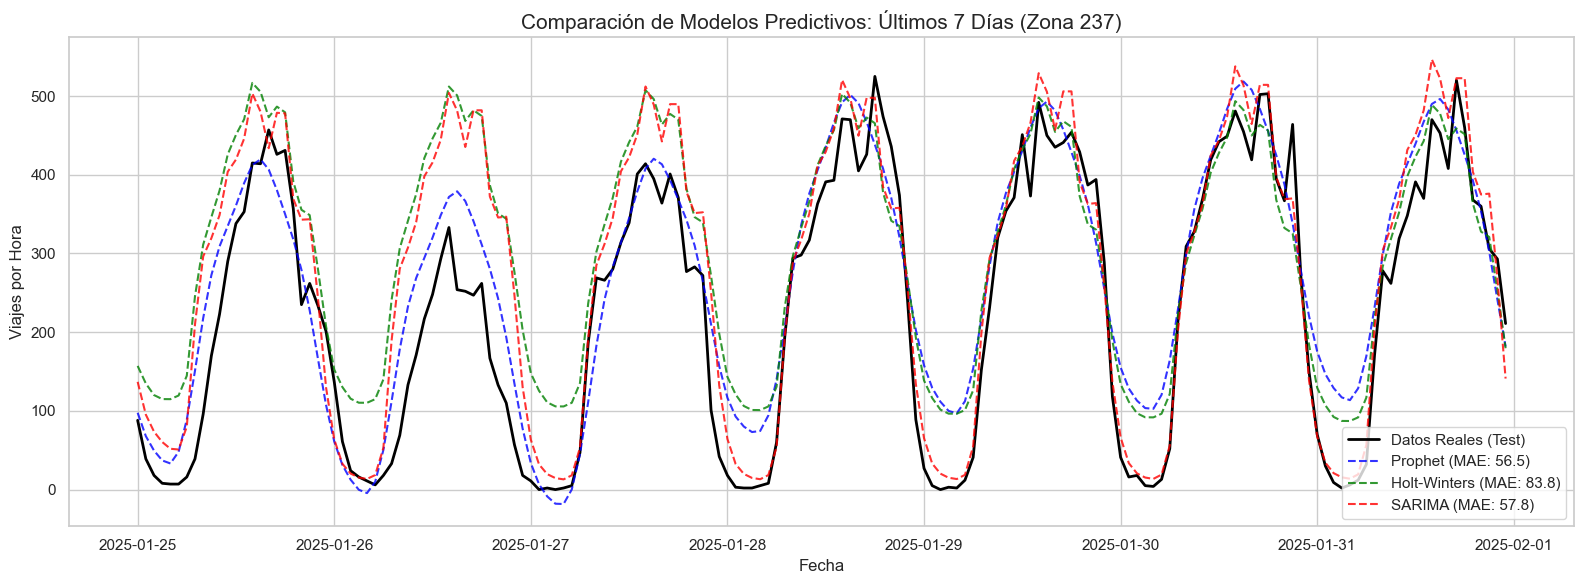

In [6]:
print("Generando comparación visual...")
import os
os.makedirs('../resultados/graficos', exist_ok=True)

plt.figure(figsize=(16, 6))
plt.plot(test.index, test.values, label='Datos Reales (Test)', color='black', linewidth=2)
plt.plot(test.index, pred_prophet, label=f'Prophet (MAE: {mae_prophet:.1f})', linestyle='--', color='blue', alpha=0.8)
plt.plot(test.index, pred_hw, label=f'Holt-Winters (MAE: {mae_hw:.1f})', linestyle='--', color='green', alpha=0.8)
plt.plot(test.index, pred_sarima, label=f'SARIMA (MAE: {mae_sarima:.1f})', linestyle='--', color='red', alpha=0.8)

plt.title('Comparación de Modelos Predictivos: Últimos 7 Días (Zona 237)', fontsize=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Viajes por Hora', fontsize=12)
plt.legend()
plt.tight_layout()

# Guardar gráfica
grafico_path = '../resultados/graficos/comparacion_modelos.png'
plt.savefig(grafico_path, dpi=300, bbox_inches='tight')
print(f"Gráfica guardada en: {grafico_path}")
plt.show()

In [7]:
print("\n=== RESUMEN DE LA COMPETENCIA ===")
resultados = pd.DataFrame({
    'Modelo': ['Prophet', 'Holt-Winters', 'SARIMA'],
    'MAE': [mae_prophet, mae_hw, mae_sarima],
    'RMSE': [rmse_prophet, rmse_hw, rmse_sarima]
}).sort_values('MAE')
display(resultados.round(2))


=== RESUMEN DE LA COMPETENCIA ===


,Modelo,MAE,RMSE
0,Prophet,56.49,67.98
2,SARIMA,57.82,81.50
1,Holt-Winters,83.83,102.75
